# Land Cover Classification Framework

The workflow will cover how to retrieve LandSat Imagery to begin development of a landcover classifier. We will use the landcover classifier to examine changes over time.

## Case Application: Great Salt Lake

The Great Salt Lake (GSL) fluctuates both from natural seasonality, year-to-year climate anomolies, and anthropogentic water use (e.g., diversions, growth, development). In today's example, we will retrieve LandSat imagery and develop a land cover classifier to examine the changes in area of the GSL over time.

In [1]:
from utils import getLandSat, plotting
import ee
import rasterio
import matplotlib.pyplot as plt
from IPython.display import Image, display

/uufs/chpc.utah.edu/common/home/u0972368/conda-envs/hyriver/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Unable to connect to VS Code server: Error in request.
Error: connect ENOENT /run/user/1819237/vscode-ipc-5f337eda-2d69-4f6c-bc21-bd447cca9c47.sock
    at PipeConnectWrap.afterConnect [as oncomplete] (node:net:1637:16) {
  errno: -2,
  code: 'ENOENT',
  syscall: 'connect',
  address: '/run/user/1819237/vscode-ipc-5f337eda-2d69-4f6c-bc21-bd447cca9c47.sock'
}



Successfully saved authorization token.
Earth Engine initialized successfully.


### LandSat Data Retrievel

Use the data retrievel functions to collect LandSat Imagery of the GSL

In [ ]:
# Define the bounding box for the region of interest (ROI), we can get these coordinates from Google Earth or any GIS software. The coordinates are in the format [xmin, ymin, xmax, ymax].
xmin = -113.2
xmax = -111.95
ymin = 40.5
ymax = 41.85

# # Get the ROI as a GeoJSON object
roi = getLandSat.get_bbox([xmin, ymin, xmax, ymax])

#call the getLandSat function to download the data for the specified ROI and time range
getLandSat.export_monthly_range_parallel( #This function parallelizes the download of Landsat data for a specified region of interest (ROI) and time range, allowing for faster data retrieval.
    roi=roi,                         #roi: The region of interest defined as a GeoJSON object, specifying the area for which the Landsat data will be downloaded.
    output_dir="data/LandSat/GSL",   #output_dir: The directory where the downloaded Landsat data will be saved. In this case, it is set to "data/LandSat/GSL".
    start_year=1985,                 #start_year: The starting year of the time range for which the Landsat data will be downloaded. In this case, it is set to 1985.
    end_year=2025,                   #end_year: The ending year of the time range for which the Landsat data will be downloaded. In this case, it is set to 2025.
    max_workers=3,                   #max_workers: The maximum number of worker threads to use for parallel processing. In this case, it is set to 3, which means that up to 3 threads will be used to download the data concurrently.
    months_before=2,                 #months_before: The number of months before the specified start year to include in the download. In this case, it is set to 2, which means that data from 2 months before the start year (1985) will also be included in the download.
    months_after=2,                  #months_after: The number of months after the specified end year to include in the download. In this case, it is set to 2, which means that data from 2 months after the end year (2025) will also be included in the download.
    reducer="median"                 #reducer: The method used to aggregate the Landsat data when multiple images are available for the same time period. In this case, it is set to "median", which means that the median value of the available images will be used for each pixel in the output data.
)

Prepared 492 monthly jobs
Generating URL ...
Generating URL ...
Generating URL ...
Please wait ...
Please wait ...
Please wait ...
Data downloaded to /uufs/chpc.utah.edu/common/home/u0972368/Hydroinformatics/Intro-to-MachineLearning/data/LandSat/GSL/GSL_1985_01.tif
Saved to data/LandSat/GSL/GSL_1985_01.tif
Finished: data/LandSat/GSL/GSL_1985_01.tif
Generating URL ...
Please wait ...
Data downloaded to /uufs/chpc.utah.edu/common/home/u0972368/Hydroinformatics/Intro-to-MachineLearning/data/LandSat/GSL/GSL_1985_03.tif
Saved to data/LandSat/GSL/GSL_1985_03.tif
Finished: data/LandSat/GSL/GSL_1985_03.tif
Data downloaded to /uufs/chpc.utah.edu/common/home/u0972368/Hydroinformatics/Intro-to-MachineLearning/data/LandSat/GSL/GSL_1985_02.tif
Saved to data/LandSat/GSL/GSL_1985_02.tif
Finished: data/LandSat/GSL/GSL_1985_02.tif
Generating URL ...
Please wait ...
Generating URL ...
Please wait ...
Data downloaded to /uufs/chpc.utah.edu/common/home/u0972368/Hydroinformatics/Intro-to-MachineLearning/da

## Plot some images

We want to plot some of the images to double check out work. 
* How does the image look?
* Is the bounding box correct?
* How is the color scaling?

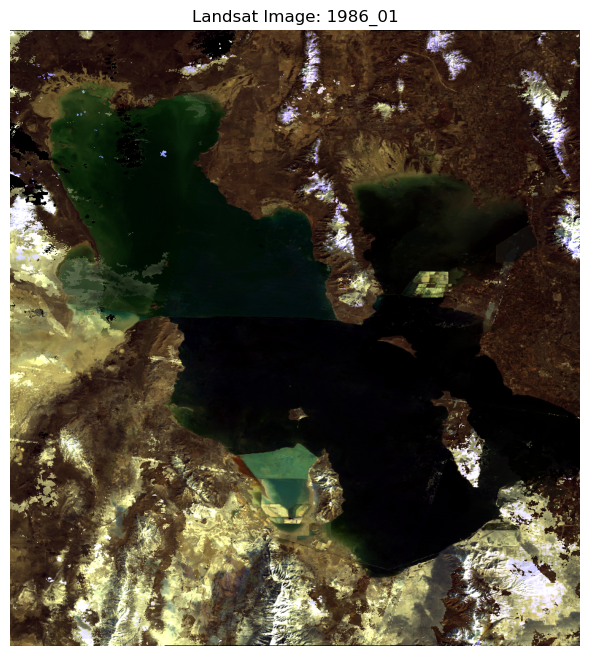

In [3]:

Path = 'data/LandSat/GSL/' #The directory where the downloaded Landsat data is saved. In this case, it is set to "data/LandSat/GSL/".
date = '1986_01' #The specific date for which the Landsat image will be plotted. In this case, it is set to '1986_01', which likely corresponds to January 1986.

# This function call for plotting the Landsat image for the specified date using the data stored in the specified directory. The function reads the relevant Landsat data from the directory, processes it, and then generates a visual representation of the image for the given date.
plotting.plot_landsat_image(Path, date)

### Exploring changes over time

A key element of the exercise is to quantitatively describe changes in GSL surface area over time. A first step is to qualitaively do this by making a time-series gif of the images and visually assess if we in fact do observed changes.

In [ ]:
plotting.make_gif_from_tifs(
    input_dir="data/LandSat/GSL",
    output_gif="data/LandSat/GSL/gsl_timelapse.gif",
    frame_duration=.8,
    max_width=400,
    font_size=40
)

display(Image(filename="data/LandSat/GSL/gsl_timelapse.gif"))

Building GIF:   0%|          | 0/485 [00:00<?, ?frame/s]

Saving GIF to data/LandSat/GSL/gsl_timelapse.gif with frame duration 0.8s...
Saved GIF to data/LandSat/GSL/gsl_timelapse.gif


### Lets trainsition to model development

Now that we have the data, we can start developing it to train our ML model in [LC_Classifier](LC_Classifier.ipynb)